In [7]:
import sys
!{sys.executable} -m pip install --upgrade nbformat

In [ ]:
%pip install seaborn matplotlib plotly

Note: you may need to restart the kernel to use updated packages.
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ---------------------------------------- 0/8 [fastjsonschema]
   ---------------------------------------- 0/8 [fastjsonschema]
   ----- ---------------------------------- 1/8 [typing-extensions]
   --------------- ------------------------ 3/8 [attrs]
   --------------- ------------------------ 3/8 [attrs]
   --------------- ------------------------ 3/8 [attrs]
   -------------------- ------------------- 4/8 [referencing]
   -------------------- ------------------- 4/8 [referencing]
   ------------------------- -------------- 5/8 [json

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


--- ANALYSIS 1: Booking Cancellation Status (The Business Pain Point) ---


C:\Users\Sude\AppData\Local\Temp\ipykernel_12148\1844206216.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




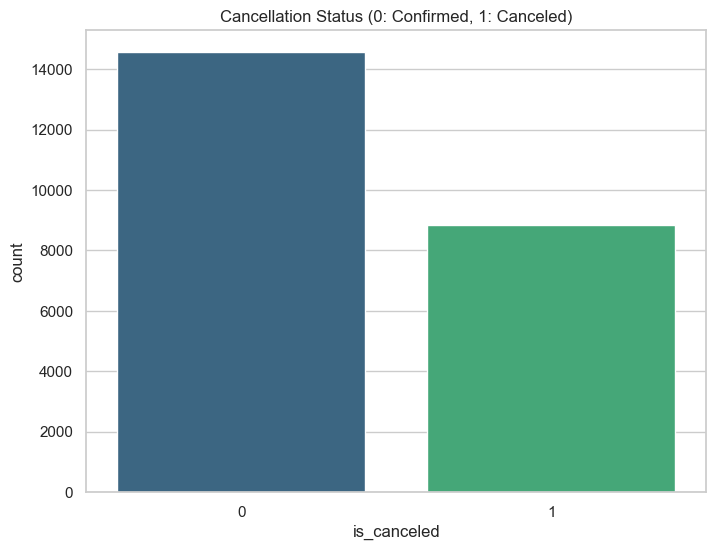


--- ANALYSIS 2: Monthly Seasonality ---


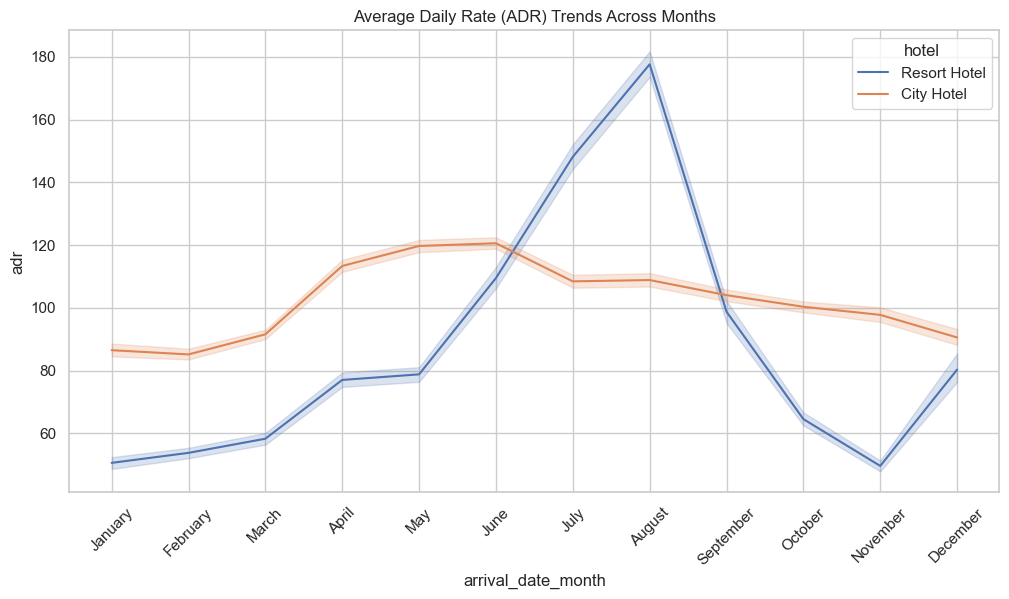


--- ANALYSIS 3: Market Segment vs Revenue (Interactive Plotly) ---

--- ANALYSIS 4: Lead Time vs Cancellation ---


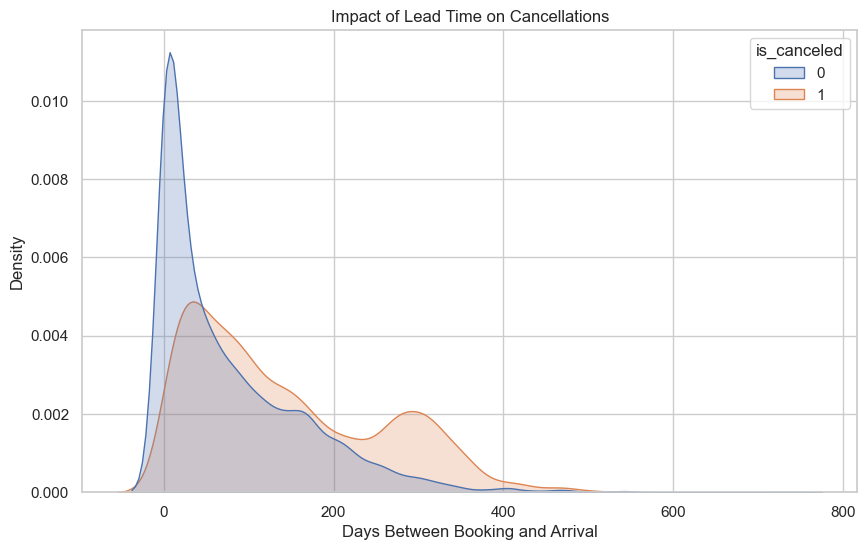

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

df = pd.read_csv('data_warehouse_cleaned.csv')

sns.set_theme(style="whitegrid")

print("--- ANALYSIS 1: Booking Cancellation Status (The Business Pain Point) ---")

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='is_canceled', data=df, palette='viridis')
ax.set_title('Cancellation Status (0: Confirmed, 1: Canceled)')
plt.show()

print("\n--- ANALYSIS 2: Monthly Seasonality ---")

ordered_months = ["January", "February", "March", "April", "May", "June", 
                  "July", "August", "September", "October", "November", "December"]
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=ordered_months, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df)
plt.title('Average Daily Rate (ADR) Trends Across Months')
plt.xticks(rotation=45)
plt.show()

print("\n--- ANALYSIS 3: Market Segment vs Revenue (Interactive Plotly) ---")

segment_revenue = df.groupby('market_segment')['adr'].mean().reset_index().sort_values(by='adr', ascending=False)

fig = px.bar(segment_revenue, x='market_segment', y='adr', 
             title='Average Revenue (ADR) by Market Segment',
             labels={'adr': 'Avg Daily Rate', 'market_segment': 'Segment'},
             color='adr', color_continuous_scale='Blues')
fig.show(renderer="browser")

print("\n--- ANALYSIS 4: Lead Time vs Cancellation ---")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False)
plt.title('Impact of Lead Time on Cancellations')
plt.xlabel('Days Between Booking and Arrival')
plt.show()